In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

#DataSet

In [2]:
df = pd.read_csv('shopping_behavior_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df['Customer ID'].value_counts(sort=True,dropna=False)

Customer ID
1       1
2       1
3       1
4       1
5       1
       ..
3896    1
3897    1
3898    1
3899    1
3900    1
Name: count, Length: 3900, dtype: int64

In [4]:
df['Customer ID'].isna().sum()

np.int64(0)

In [5]:
df['Customer ID'].info()

<class 'pandas.Series'>
RangeIndex: 3900 entries, 0 to 3899
Series name: Customer ID
Non-Null Count  Dtype
--------------  -----
3900 non-null   int64
dtypes: int64(1)
memory usage: 30.6 KB


In [6]:
df.set_index('Customer ID', inplace=True)
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 1 to 3900
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3900 non-null   int64  
 1   Gender                  3900 non-null   str    
 2   Item Purchased          3900 non-null   str    
 3   Category                3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   int64  
 5   Location                3900 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           3900 non-null   float64
 10  Subscription Status     3900 non-null   str    
 11  Shipping Type           3900 non-null   str    
 12  Discount Applied        3900 non-null   str    
 13  Promo Code Used         3900 non-null   str    
 14  Previous Purchases      3900 non-null   int64  
 15

# Handle only if missing values exist

In [8]:
# Handle only if missing values exist

if df.isnull().sum().sum() > 0:

    # Numeric columns
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


    # Categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns

    if len(categorical_cols) > 0:
        df[categorical_cols] = df[categorical_cols].fillna(
            df[categorical_cols].mode().iloc[0]
        )

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())


Missing Values After Handling:

Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


<Axes: xlabel='Age', ylabel='Count'>

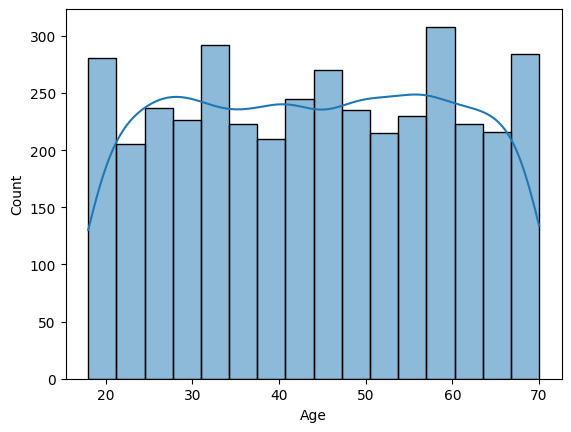

In [9]:
sns.histplot(df['Age'],kde=True) #Age distribution of the data

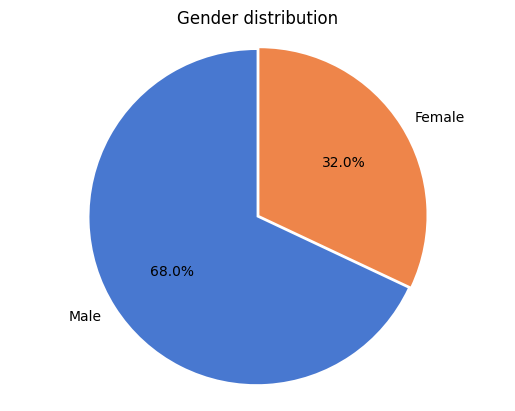

Statistics
Gender
Male      2652
Female    1248
Name: count, dtype: int64


In [10]:
# Gender distribution
counts = df['Gender'].value_counts() #counting the number of a particular category.
plt.pie(counts, explode= (0.01,0.01), labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('muted')) #pie chart for the
#variable counts as it has the number of category, explode is the distance between the pies, labels are the index values that is Male and Female,
#autopct is the labelling of the slices, startangle is the angle at which the graph starts, colors are taken from the sns color palette
plt.title(f'Gender distribution') #title of the graph
plt.axis('equal') #the axis are distributed equally
plt.show() # display the Graph
print('Statistics') #displaying the Statistics
print(counts)

C:\Users\simpl\AppData\Local\Temp\ipykernel_22684\2815694325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Item Purchased', data=df, palette = 'rainbow') #x is the column we would want to plot, data is the dataframe we will take that column from


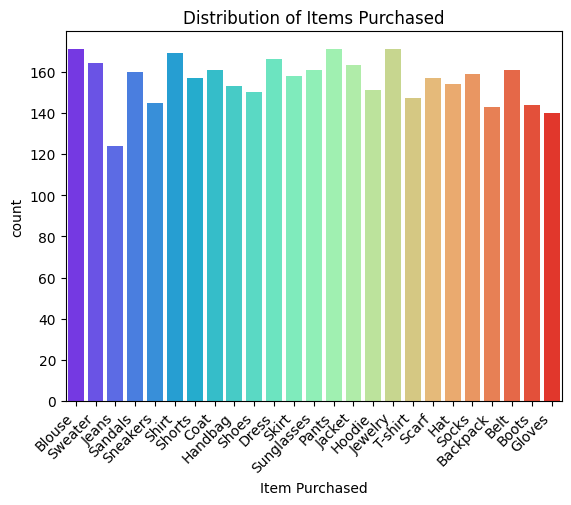

Statistics
Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64


In [11]:
#Plotting the count plot.
sns.countplot(x='Item Purchased', data=df, palette = 'rainbow') #x is the column we would want to plot, data is the dataframe we will take that column from
# palette is the color of the graph
plt.xticks(rotation=45, ha='right') #To avoid overlapping of the labels, we will rotate them by 45 to the right
plt.title(f'Distribution of Items Purchased') #Title of the graph
plt.show()
print('Statistics')
print(df['Item Purchased'].value_counts())

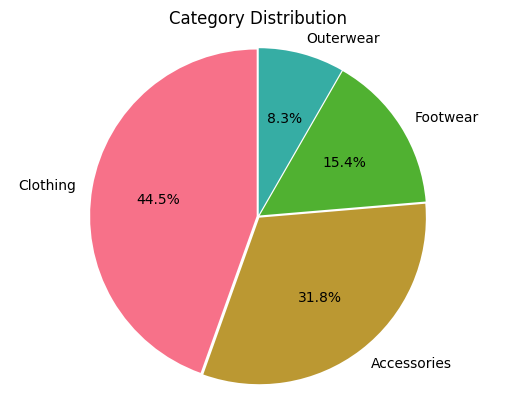

Statistics
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


In [12]:
cat= df['Category'].value_counts()
plt.pie(cat, explode= (0.01,0.01,0.01,0.01), labels=cat.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('husl'))
plt.title('Category Distribution')
plt.axis('equal')
plt.show()
print('Statistics')
print(cat)

C:\Users\simpl\AppData\Local\Temp\ipykernel_22684\2235376210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Purchase Amount (USD)', data=df, palette = 'Set2')


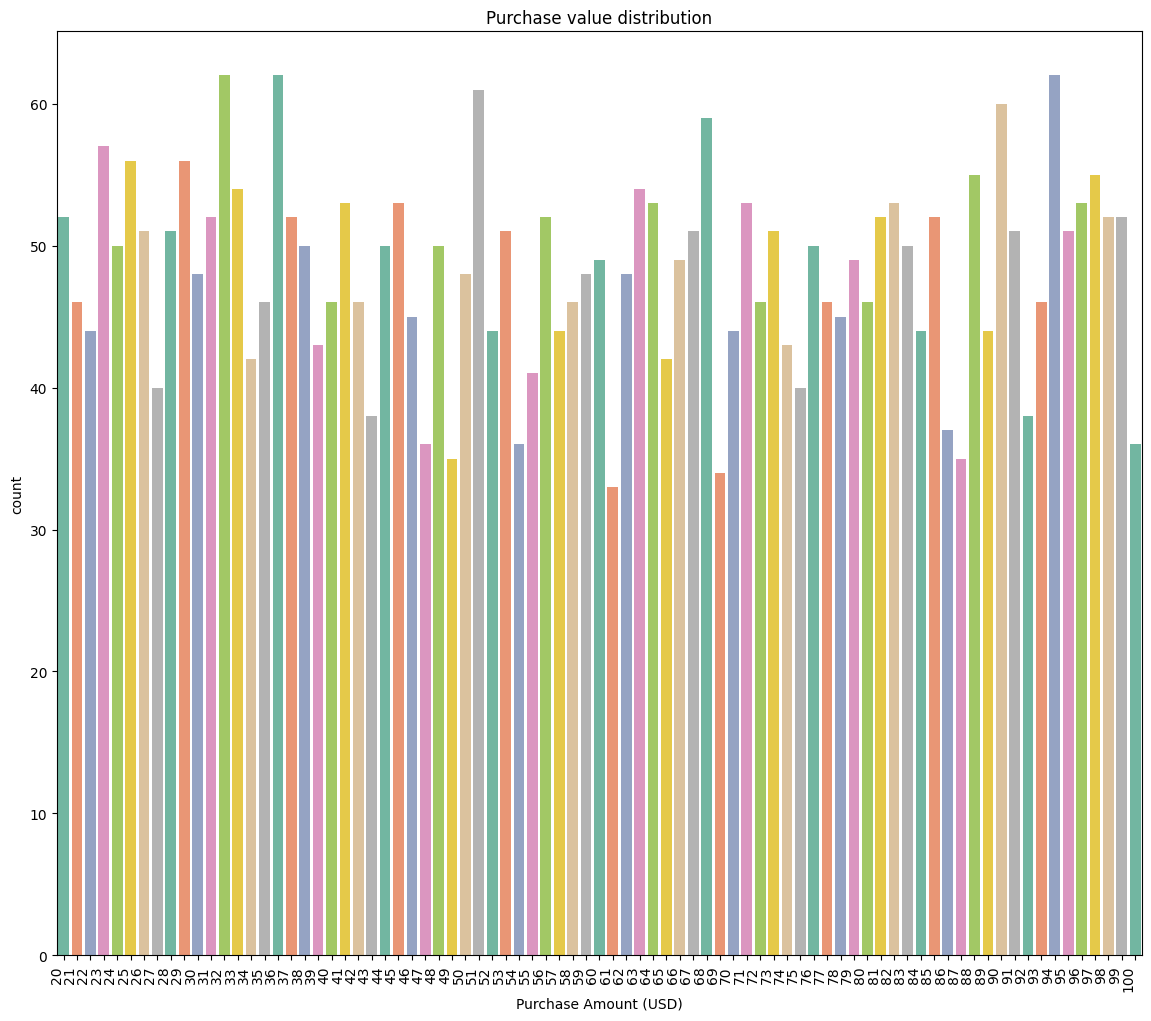

Statistics
Purchase Amount (USD)
36    62
94    62
32    62
51    61
90    60
      ..
47    36
49    35
87    35
69    34
61    33
Name: count, Length: 81, dtype: int64


In [13]:
plt.figure(figsize=(14,12))
sns.countplot(x='Purchase Amount (USD)', data=df, palette = 'Set2') 
plt.xticks(rotation=90, ha='right') 
plt.title(f'Purchase value distribution') #Title of the graph
plt.show()
print('Statistics')
print(df['Purchase Amount (USD)'].value_counts())

C:\Users\simpl\AppData\Local\Temp\ipykernel_22684\321746875.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Location', data=df, palette = 'flare')


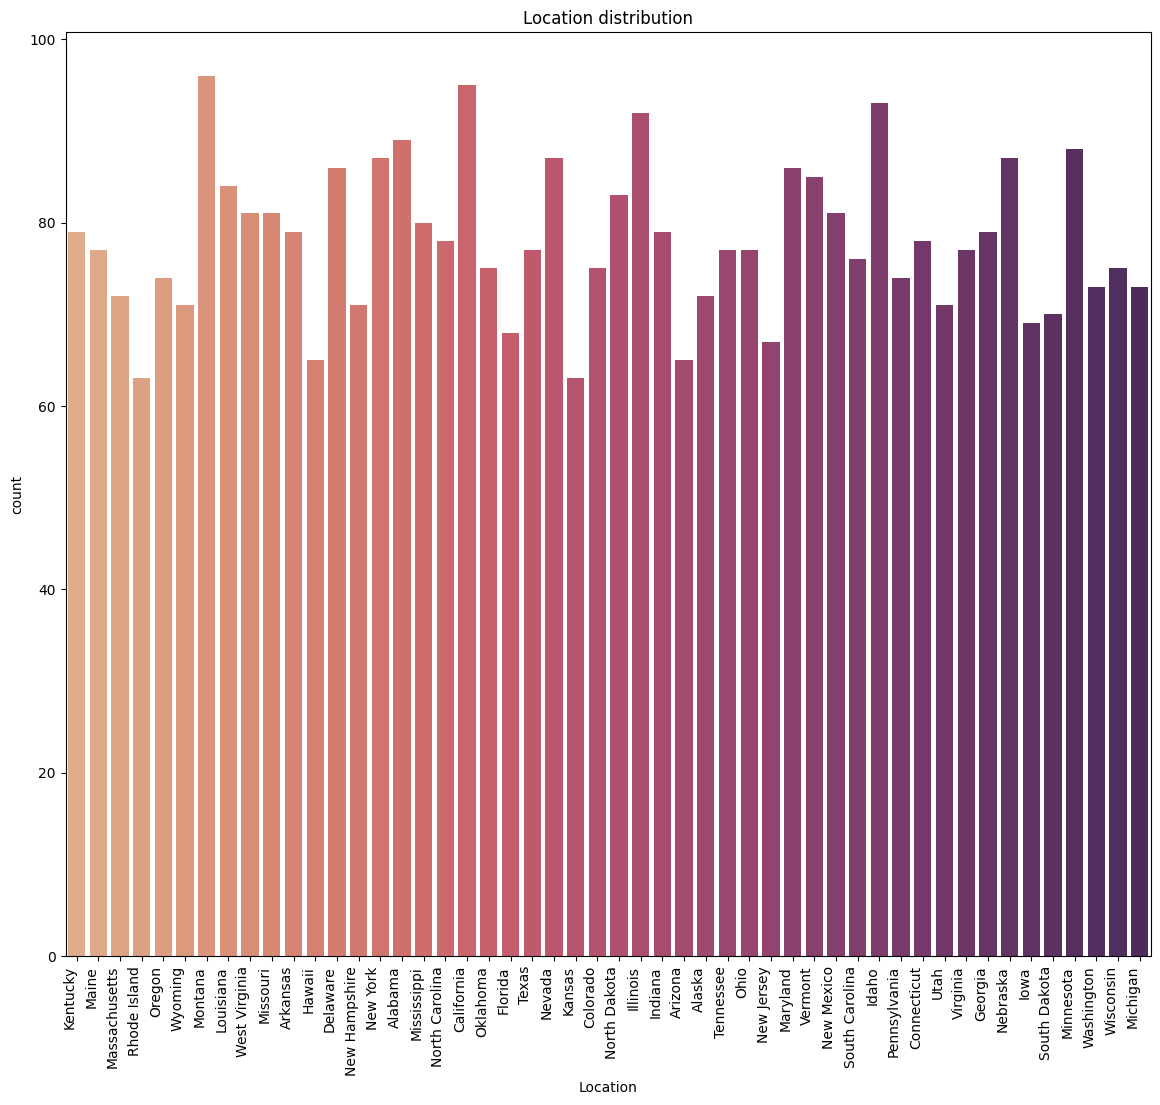

Statistics
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
North Dakota      83
West Virginia     81
Missouri          81
New Mexico        81
Mississippi       80
Kentucky          79
Arkansas          79
Indiana           79
Georgia           79
North Carolina    78
Connecticut       78
Maine             77
Texas             77
Tennessee         77
Ohio              77
Virginia          77
South Carolina    76
Oklahoma          75
Colorado          75
Wisconsin         75
Oregon            74
Pennsylvania      74
Washington        73
Michigan          73
Massachusetts     72
Alaska            72
Wyoming           71
New Hampshire     71
Utah              71
South Dakota      70
Iowa              69
Florida           68
New Jersey        67
Hawaii        

In [14]:
plt.figure(figsize=(14,12))
sns.countplot(x='Location', data=df, palette = 'flare') 
plt.xticks(rotation=90, ha='right') 
plt.title(f'Location distribution') #Title of the graph
plt.show()
print('Statistics')
print(df['Location'].value_counts())

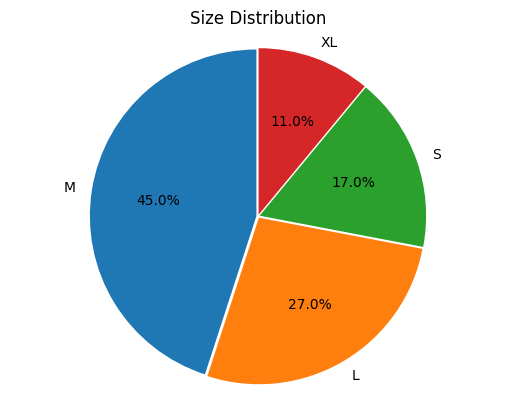

Statistics
Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64


In [15]:
sz = df['Size'].value_counts()
plt.pie(sz, explode= (0.01,0.01,0.01,0.01), labels=sz.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette())
plt.title('Size Distribution')
plt.axis('equal')
plt.show()
print('Statistics')
print(sz)

C:\Users\simpl\AppData\Local\Temp\ipykernel_22684\1087635408.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Color', data=df, palette = 'blend:#7AB,#EDA')


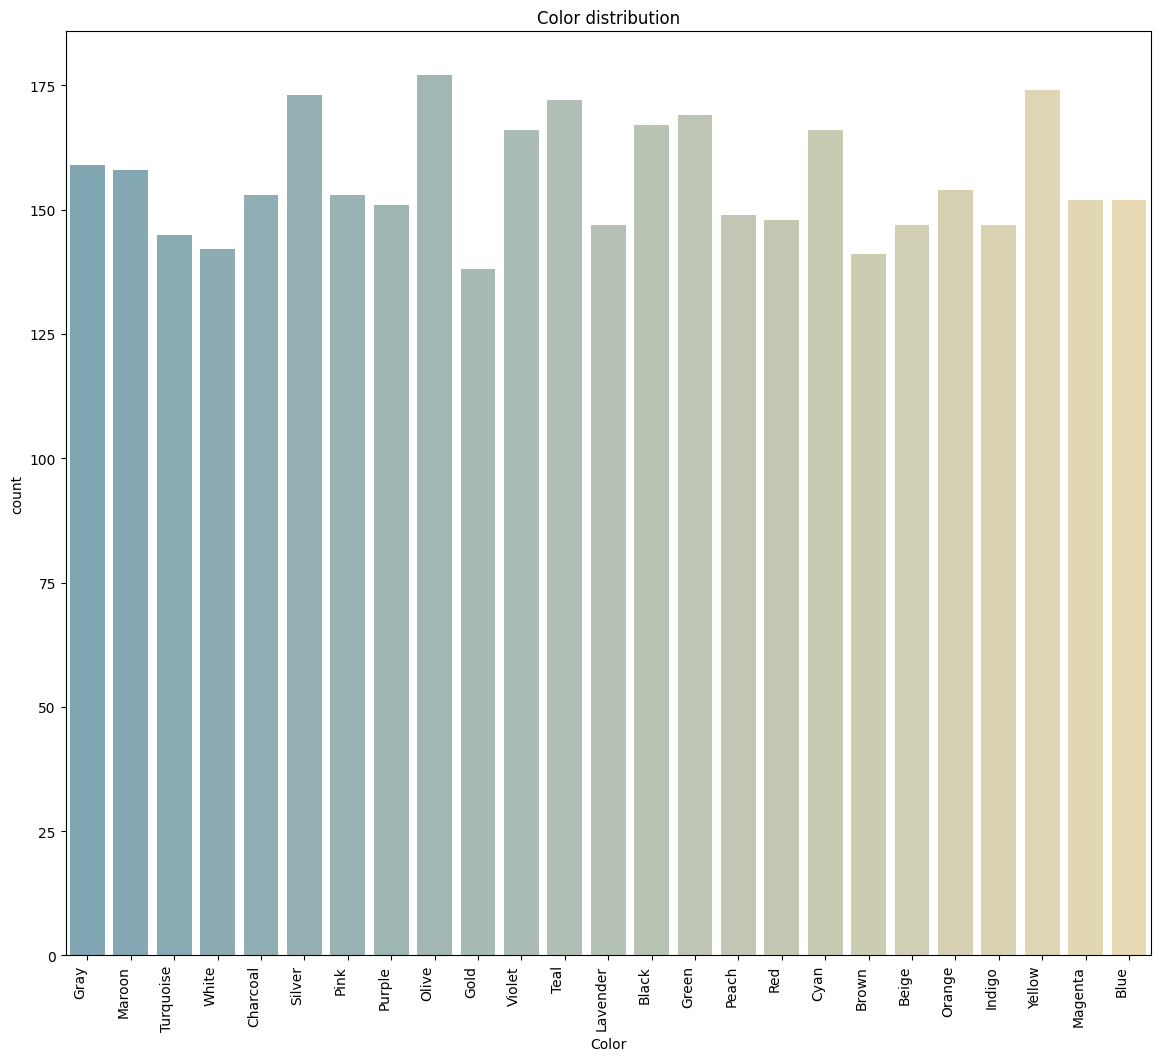

Statistics
Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Violet       166
Cyan         166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Magenta      152
Blue         152
Purple       151
Peach        149
Red          148
Lavender     147
Beige        147
Indigo       147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(14,12))
sns.countplot(x='Color', data=df, palette = 'blend:#7AB,#EDA') 
plt.xticks(rotation=90, ha='right') 
plt.title(f'Color distribution') #Title of the graph
plt.show()
print('Statistics')
print(df['Color'].value_counts())

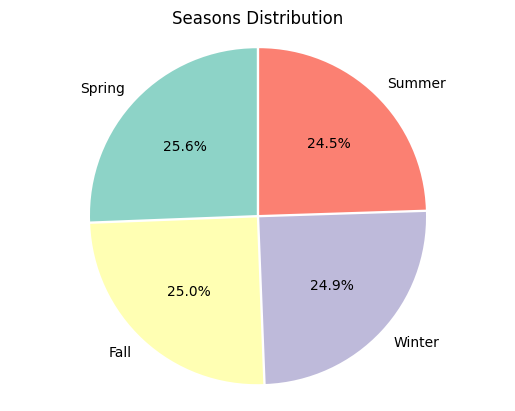

Statistics
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


In [17]:
ssn = df['Season'].value_counts()
plt.pie(ssn, explode= (0.01,0.01,0.01,0.01), labels=ssn.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
plt.title('Seasons Distribution')
plt.axis('equal')
plt.show()
print('Statistics')
print(ssn)

C:\Users\simpl\AppData\Local\Temp\ipykernel_22684\3812181631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Review Rating', data=df, palette = 'pastel6')


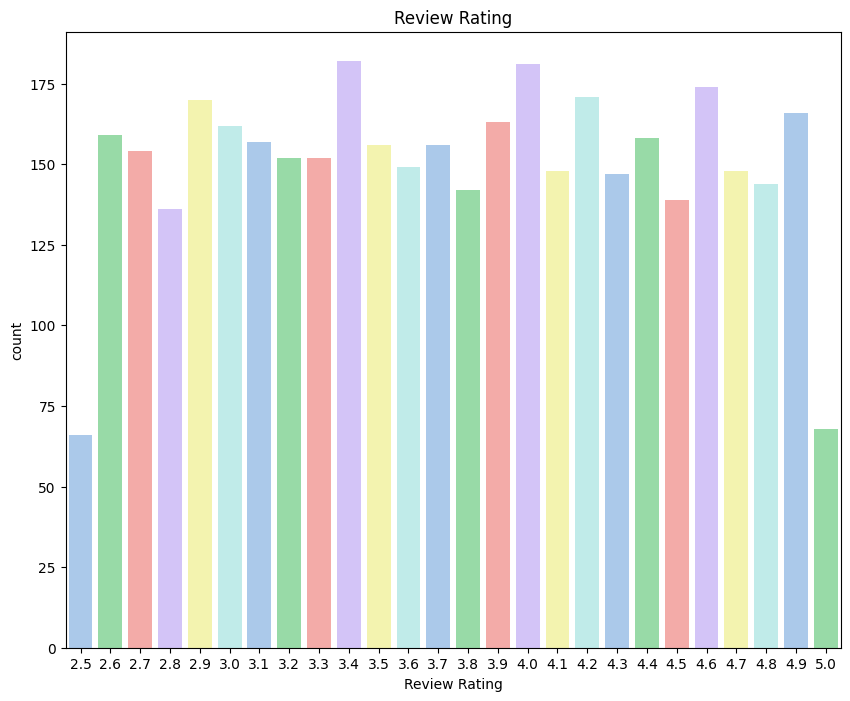

Statistics
Review Rating
3.4    182
4.0    181
4.6    174
4.2    171
2.9    170
4.9    166
3.9    163
3.0    162
2.6    159
4.4    158
3.1    157
3.5    156
3.7    156
2.7    154
3.2    152
3.3    152
3.6    149
4.1    148
4.7    148
4.3    147
4.8    144
3.8    142
4.5    139
2.8    136
5.0     68
2.5     66
Name: count, dtype: int64


In [18]:
plt.figure(figsize=(10,8))
sns.countplot(x='Review Rating', data=df, palette = 'pastel6') 
plt.title(f'Review Rating')
plt.show()
print('Statistics')
print(df['Review Rating'].value_counts())

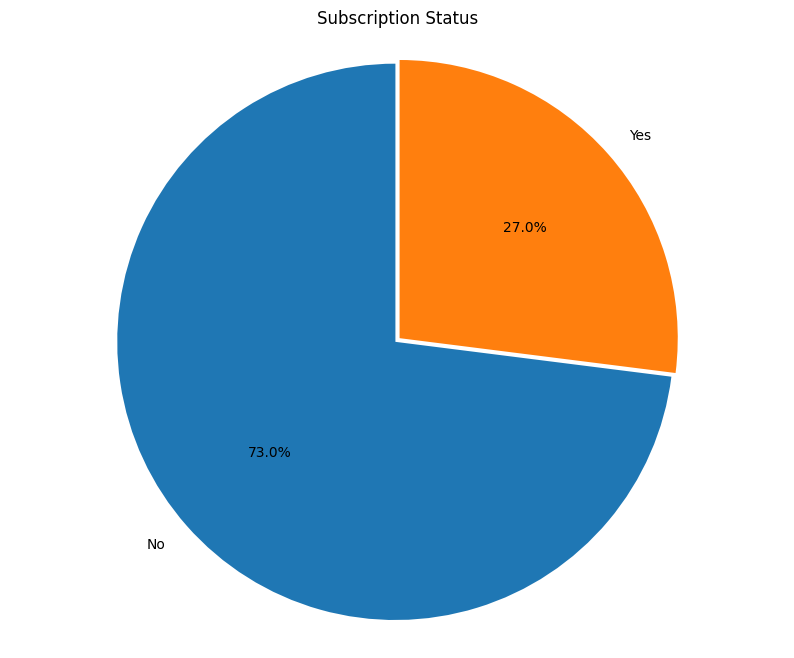

Statistics
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(10,8))
subs= df['Subscription Status'].value_counts()
plt.pie(subs, explode= (0.01,0.01), labels=subs.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette(None))
plt.title('Subscription Status')
plt.axis('equal')
plt.show()
print('Statistics')
print(cat)

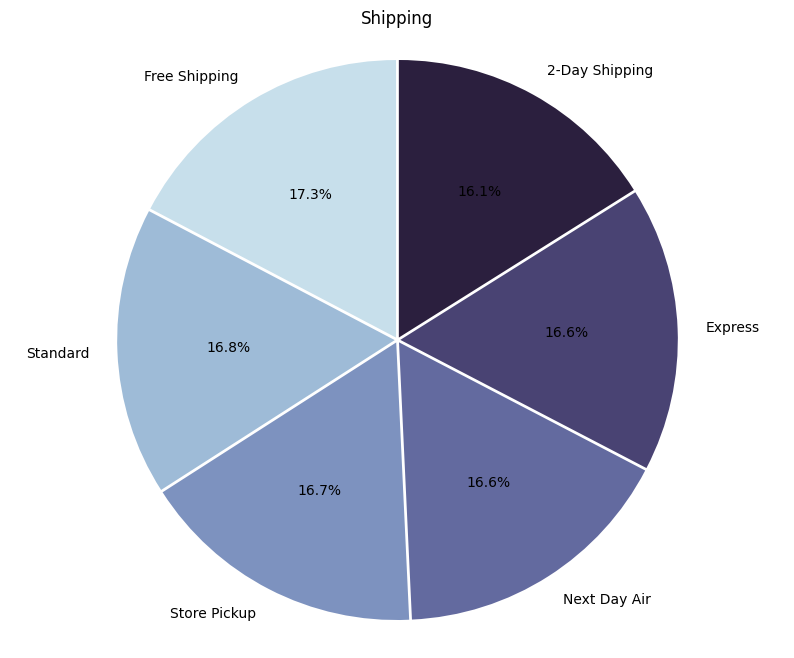

Statistics
Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(10,8))
ship= df['Shipping Type'].value_counts()
plt.pie(ship, explode= (0.01,0.01,0.01,0.01,0.01,0.01), labels=ship.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('ch:s=.25,rot=-.25'))
plt.title('Shipping')
plt.axis('equal')
plt.show()
print('Statistics')
print(ship)

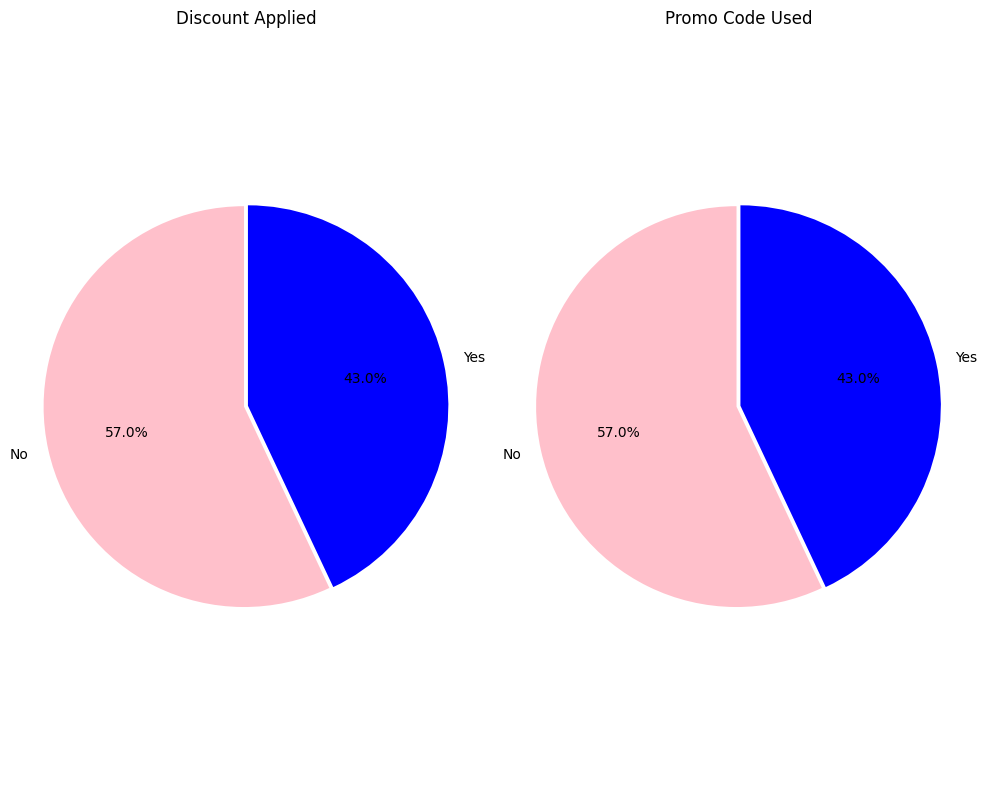

Statistics
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64


In [21]:
dsc= df['Discount Applied'].value_counts()
pmc= df['Promo Code Used'].value_counts()
explode = (0.01,0.01)
color= ['pink','blue']
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,8))

ax1.pie(dsc, explode=explode, labels=dsc.index, colors=color, autopct='%1.1f%%', startangle=90)
ax1.set_title('Discount Applied')
ax1.axis('equal')

ax2.pie(pmc, explode=explode, labels=pmc.index, colors=color, autopct='%1.1f%%', startangle=90)
ax2.set_title('Promo Code Used')
ax2.axis('equal')

plt.tight_layout()

plt.show()
print('Statistics')
print(dsc)
print(pmc)

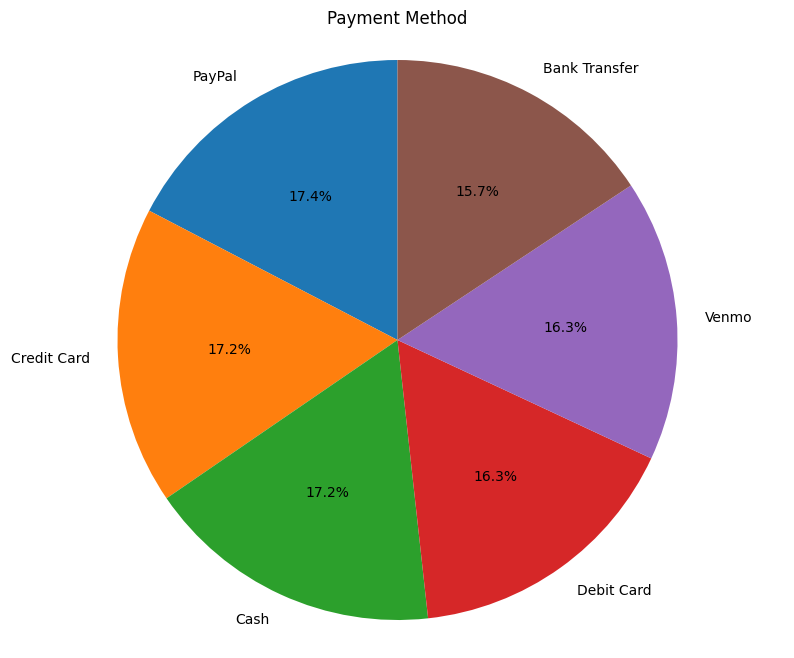

Statistics
Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(10,8))
pym= df['Payment Method'].value_counts()
plt.pie(pym, labels=pym.index, autopct='%1.1f%%', startangle=90)
plt.title('Payment Method')
plt.axis('equal')
plt.show()
print('Statistics')
print(pym)

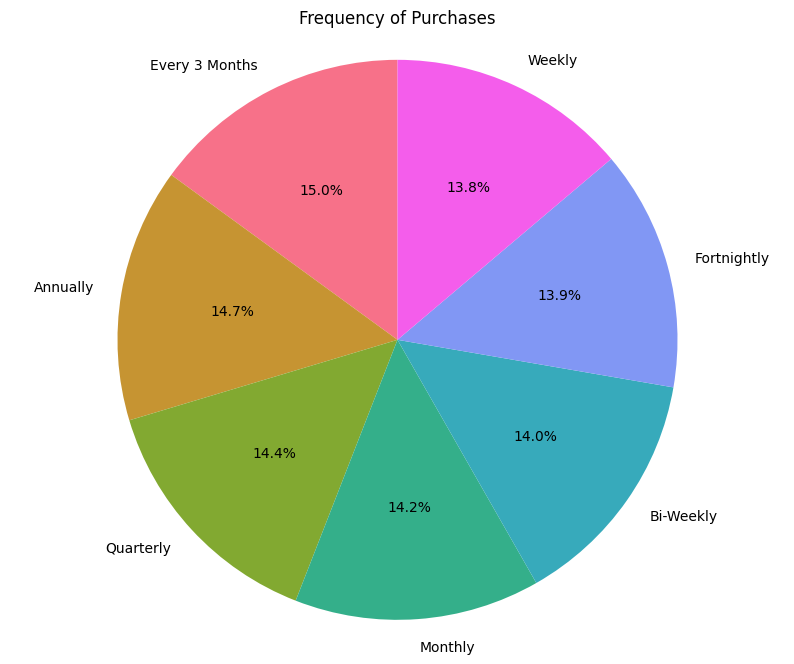

Statistics
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(10,8))
frq= df['Frequency of Purchases'].value_counts()
plt.pie(frq, labels=frq.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl", 7))
plt.title('Frequency of Purchases')
plt.axis('equal')
plt.show()
print('Statistics')
print(frq)


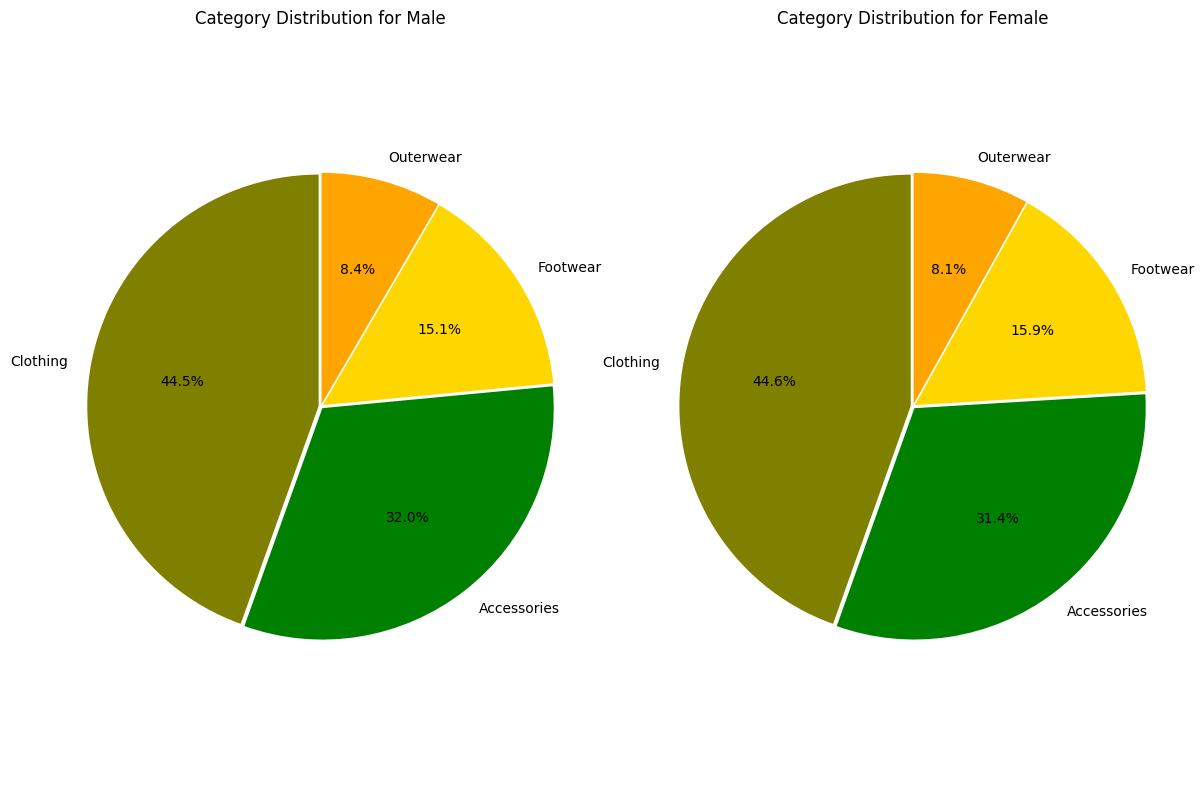

Statistics
Category
Clothing       1181
Accessories     848
Footwear        400
Outerwear       223
Name: count, dtype: int64
Category
Clothing       556
Accessories    392
Footwear       199
Outerwear      101
Name: count, dtype: int64


In [24]:
male = df.groupby('Gender').get_group('Male')
female = df.groupby('Gender').get_group('Female')

c= male['Category'].value_counts()
d= female['Category'].value_counts()
color= ['olive','green','gold','orange']
explode = (0.01,0.01,0.01,0.01)
fig, (ax3,ax4) = plt.subplots(1,2,figsize=(12,8))

ax3.pie(c, explode=explode, labels=c.index, colors=color, autopct='%1.1f%%', startangle=90)
ax3.set_title('Category Distribution for Male')
ax3.axis('equal')

ax4.pie(d, explode=explode, labels=d.index, colors=color, autopct='%1.1f%%', startangle=90)
ax4.set_title('Category Distribution for Female')
ax4.axis('equal')

plt.tight_layout()
plt.show()
print('Statistics')
print(c)
print(d)

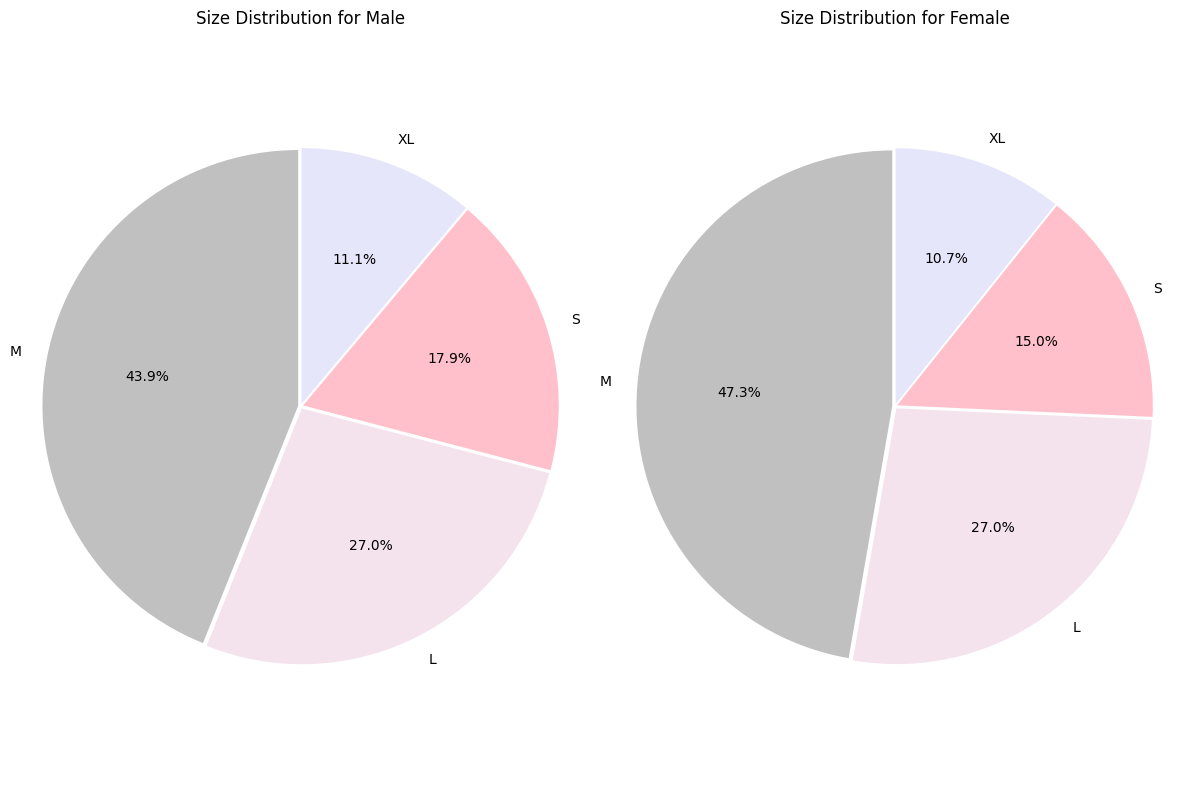

Statistics
Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


In [25]:
sze1 = male['Size'].value_counts()
sze2 = female['Size'].value_counts()

color= ['silver','#f4e2ed','pink','lavender']
explode = (0.01,0.01,0.01,0.01)
fig, (ax5,ax6) = plt.subplots(1,2,figsize=(12,8))

ax5.pie(sze1, explode=explode, labels=sze1.index, colors=color, autopct='%1.1f%%', startangle=90)
ax5.set_title('Size Distribution for Male')
ax5.axis('equal')

ax6.pie(sze2, explode=explode, labels=sze2.index, colors=color, autopct='%1.1f%%', startangle=90)
ax6.set_title('Size Distribution for Female')
ax6.axis('equal')

plt.tight_layout()
plt.show()
print('Statistics')
print(sze1)
print(sze2)

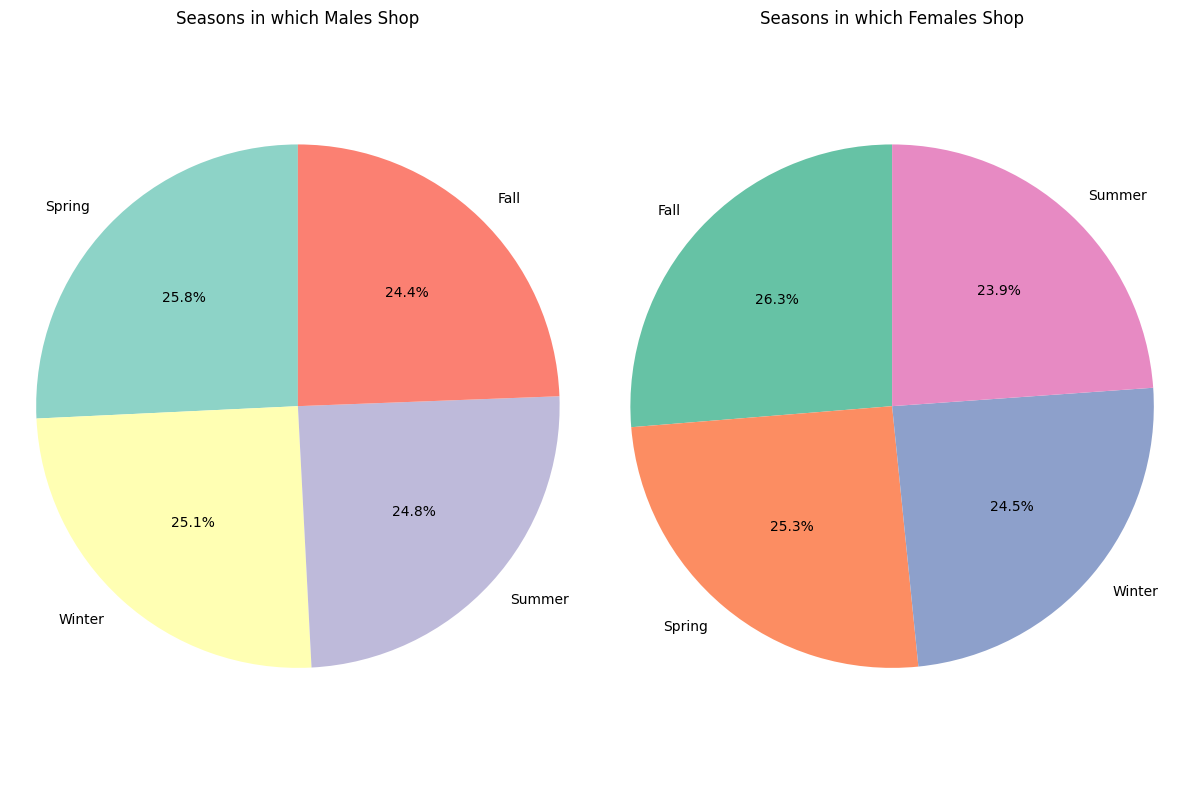

Statistics
Season
Spring    683
Winter    665
Summer    657
Fall      647
Name: count, dtype: int64
Season
Fall      328
Spring    316
Winter    306
Summer    298
Name: count, dtype: int64


In [26]:
seas1 = male['Season'].value_counts()
seas2 = female['Season'].value_counts()

fig, (ax7,ax8) = plt.subplots(1,2,figsize=(12,8))

ax7.pie(seas1, labels=seas1.index, colors=sns.color_palette('Set3'), autopct='%1.1f%%', startangle=90)
ax7.set_title('Seasons in which Males Shop')
ax7.axis('equal')

ax8.pie(seas2, labels=seas2.index, colors=sns.color_palette('Set2'), autopct='%1.1f%%', startangle=90)
ax8.set_title('Seasons in which Females Shop')
ax8.axis('equal')

plt.tight_layout()
plt.show()
print('Statistics')
print(seas1)
print(seas2)

In [27]:
numerical_cols = df.select_dtypes(include=['number'])
numerical_cols.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


R² Score of the Random Forest Regressor: -0.0301


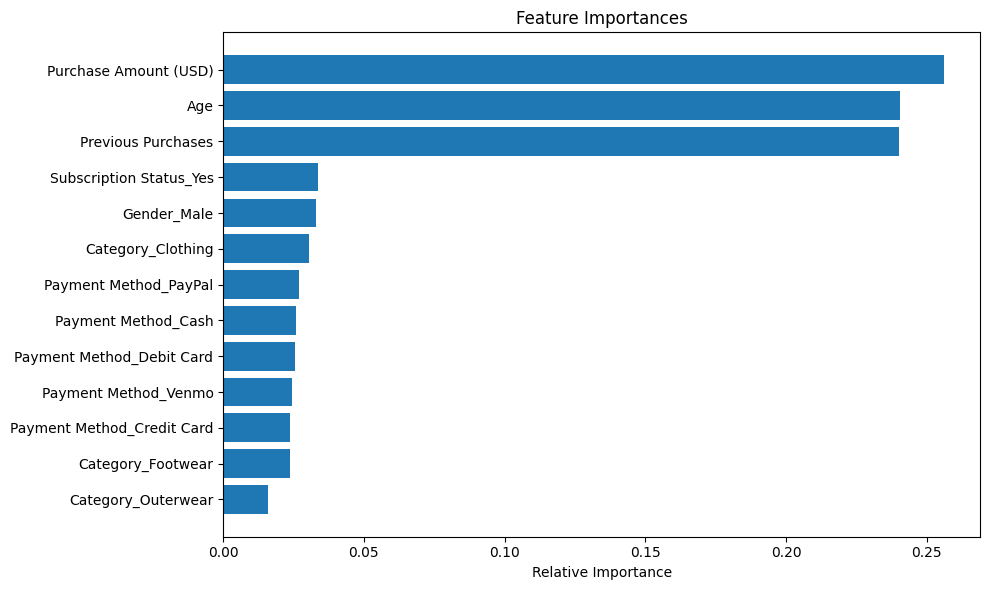

In [28]:
# Prepare the data for prediction

# Choose features and target. For illustrative purpose, we use a subset of features.
features = ['Age', 'Purchase Amount (USD)', 'Previous Purchases', 'Gender', 'Category', 'Subscription Status', 'Payment Method']
target = 'Review Rating'

# Subset the dataframe to include only the features that exist in the dataframe.

available_features = [col for col in features if col in df.columns]
X = df[available_features].copy()
y = df[target].copy()

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare the data for prediction

# Choose features and target. For illustrative purpose, we use a subset of features.
features = ['Age', 'Purchase Amount (USD)', 'Previous Purchases', 'Gender', 'Category', 'Subscription Status', 'Payment Method']
target = 'Review Rating'

# Subset the dataframe to include only the features that exist in the dataframe.

available_features = [col for col in features if col in df.columns]
X = df[available_features].copy()
y = df[target].copy()

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predict on the test set and calculate the R² score
y_pred = rf_model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f'R² Score of the Random Forest Regressor: {score:.4f}')

# Feature importance visualization using permutation importance like bar plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [5]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report

#Load Dataset

In [6]:
#Load Dataset
df = pd.read_csv("shopping_behavior_updated.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows")
print(df.head())

Dataset Shape: (3900, 18)

First 5 Rows
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type

#Problem Definition (Binary Classification)

In [7]:
#Problem Definition (Binary Classification)
#Target Column = Subscription Status

print(df['Subscription Status'].unique())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str


#Convert to binary

In [8]:
#Convert to binary

df['Subscription Status'] = df['Subscription Status'].map({'Yes':1,'No':0})

print(df['Subscription Status'].value_counts())

Subscription Status
0    2847
1    1053
Name: count, dtype: int64


#Drop Column (Customer ID)

In [9]:
#Drop Column (Customer ID)

df = df.drop(columns=['Customer ID'])

print("Columns after dropping ID:")
print(df.columns)

Columns after dropping ID:
Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='str')


#Avg Purchase Value

In [10]:
#Avg Purchase Value

df['Avg Purchase Value'] = df['Purchase Amount (USD)'] / (df['Previous Purchases'] + 1)

print(df[['Purchase Amount (USD)','Previous Purchases','Avg Purchase Value']].head())

   Purchase Amount (USD)  Previous Purchases  Avg Purchase Value
0                     53                  14            3.533333
1                     64                   2           21.333333
2                     73                  23            3.041667
3                     90                  49            1.800000
4                     49                  31            1.531250


#Discount Sensitivity Index

In [11]:
#Discount Sensitivity Index

df['Discount Applied'] = df['Discount Applied'].map({'Yes':1,'No':0})
df['Promo Code Used'] = df['Promo Code Used'].map({'Yes':1,'No':0})

df['Discount Sensitivity'] = df['Discount Applied'] + df['Promo Code Used']

print(df[['Discount Applied','Promo Code Used','Discount Sensitivity']].head())

   Discount Applied  Promo Code Used  Discount Sensitivity
0                 1                1                     2
1                 1                1                     2
2                 1                1                     2
3                 1                1                     2
4                 1                1                     2


#Engagement Score

In [14]:
#Engagement Score

df['Engagement Score'] = df['Review Rating'] + df['Previous Purchases']

print(df[['Review Rating','Previous Purchases','Engagement Score']].head())

   Review Rating  Previous Purchases  Engagement Score
0            3.1                  14              17.1
1            3.1                   2               5.1
2            3.1                  23              26.1
3            3.5                  49              52.5
4            2.7                  31              33.7


#Split X and Y

In [38]:
# PART 1 — Subscription

X1 = df.drop('Subscription Status', axis=1)
y1 = df['Subscription Status']

# 🔥 FORCE ENCODING
X1 = pd.get_dummies(X1, drop_first=True)

# 🔥 RESET INDEX (important sometimes)
X1 = X1.reset_index(drop=True)
y1 = y1.reset_index(drop=True)

# Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [15]:
#Split X1 and Y1

X1 = df.drop('Subscription Status', axis=1)
y1 = df['Subscription Status']

print("X1 shape:",X1.shape)
print("y1 shape:",y1.shape)

X1 shape: (3900, 19)
y1 shape: (3900,)


#Train Test Split

In [16]:
#Train Test Split

X1_train,X1_test,y1_train,y1_test = train_test_split(
    X1,y1,test_size=0.2,random_state=42
)

print("Train size:",X1_train.shape)
print("Test size:",X1_test.shape)

Train size: (3120, 19)
Test size: (780, 19)


#Separate Numerical & Categorical Columns

In [17]:
#Separate Numerical & Categorical Columns

num_cols = X1.select_dtypes(include=['int64','float64']).columns
cat_cols = X1.select_dtypes(include=['object']).columns

print("Numerical Columns:",num_cols)
print("Categorical Columns:",cat_cols)

Numerical Columns: Index(['Age', 'Purchase Amount (USD)', 'Review Rating', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Avg Purchase Value',
       'Discount Sensitivity', 'Engagement Score'],
      dtype='str')
Categorical Columns: Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases'],
      dtype='str')


C:\Users\simpl\AppData\Local\Temp\ipykernel_15252\2690852134.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X1.select_dtypes(include=['object']).columns


#Preprocessing Pipeline

In [18]:
#Preprocessing Pipeline
#Numerical → StandardScaler
#Categorical → OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

#Feature Selection (ANOVA)

In [19]:
#Feature Selection (ANOVA)

X1_encoded = pd.get_dummies(X1)

selector = SelectKBest(score_func=f_classif,k=5)

X1_new = selector.fit_transform(X1_encoded,y1)

selected_features = X1_encoded.columns[selector.get_support()]

print("Top 5 Features from ANOVA:")
print(selected_features)

Top 5 Features from ANOVA:
Index(['Discount Applied', 'Promo Code Used', 'Discount Sensitivity',
       'Gender_Female', 'Gender_Male'],
      dtype='str')


#Create Top-5 dataset

In [20]:
#Create Top-5 dataset

X1_top51 = X1_encoded[selected_features]

X1_train51,X1_test51,y1_train51,y1_test51 = train_test_split(
    X1_top51,y1,test_size=0.2,random_state=42
)

#Model Training (FULL DATASET)

In [21]:
#Model Training (FULL DATASET)
#Logistic Regression

pipe_lr = Pipeline([
('preprocessor',preprocessor),
('model',LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X1_train,y1_train)

pred_lr = pipe_lr.predict(X1_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y1_test,pred_lr))

Logistic Regression Accuracy: 0.8012820512820513


In [22]:
#Random Forest

pipe_rf = Pipeline([
('preprocessor',preprocessor),
('model',RandomForestClassifier())
])

pipe_rf.fit(X1_train,y1_train)

pred_rf = pipe_rf.predict(X1_test)

print("Random Forest Accuracy:",
      accuracy_score(y1_test,pred_rf))

Random Forest Accuracy: 0.8256410256410256


In [23]:
#XGBoost

xgb = XGBClassifier()

pipe_xgb = Pipeline([
('preprocessor',preprocessor),
('model',xgb)
])

pipe_xgb.fit(X1_train,y1_train)

pred_xgb = pipe_xgb.predict(X1_test)

print("XGBoost Accuracy:",
      accuracy_score(y1_test,pred_xgb))

XGBoost Accuracy: 0.8102564102564103


In [24]:
#LightGBM
lgbm = LGBMClassifier()

lgbm = LGBMClassifier(verbose=-1)
pipe_lgb = Pipeline([
('preprocessor',preprocessor),
('model',lgbm)
])

pipe_lgb.fit(X1_train,y1_train)

pred_lgb = pipe_lgb.predict(X1_test)

print("LightGBM Accuracy:",
      accuracy_score(y1_test,pred_lgb))

LightGBM Accuracy: 0.8102564102564103


C:\Users\simpl\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
#CatBoost

cat = CatBoostClassifier(verbose=0)

pipe_cat = Pipeline([
('preprocessor',preprocessor),
('model',cat)
])

pipe_cat.fit(X1_train,y1_train)

pred_cat = pipe_cat.predict(X1_test)

print("CatBoost Accuracy:",
      accuracy_score(y1_test,pred_cat))

CatBoost Accuracy: 0.8282051282051283


#Models on Top-5 Features

In [26]:
#Models on Top-5 Features

models = {
"Logistic Regression":LogisticRegression(max_iter=1000),
"Random Forest":RandomForestClassifier(),
"XGBoost":XGBClassifier(),
"LightGBM":LGBMClassifier(),
"CatBoost":CatBoostClassifier(verbose=0)
}

for name,model in models.items():
    
    model.fit(X1_train51,y1_train51)
    
    pred=model.predict(X1_test51)
    
    acc=accuracy_score(y1_test51,pred)
    
    print(name,"Accuracy:",acc)

Logistic Regression Accuracy: 0.8256410256410256
Random Forest Accuracy: 0.8256410256410256
XGBoost Accuracy: 0.8256410256410256
LightGBM Accuracy: 0.8256410256410256
CatBoost Accuracy: 0.8256410256410256


#changing target column

In [27]:
# Create threshold using median
threshold = df['Purchase Amount (USD)'].median()

# Create Spender column
df['Spender'] = df['Purchase Amount (USD)'].apply(lambda x: 1 if x >= threshold else 0)

# Check result
print(df['Spender'].value_counts())

Spender
1    1963
0    1937
Name: count, dtype: int64


In [28]:
X2 = df.drop(['Spender', 'Purchase Amount (USD)'], axis=1)
y2 = df['Spender']

In [29]:
cat_cols = X2.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Shipping Type', 'Payment Method', 'Frequency of Purchases'],
      dtype='str')


C:\Users\simpl\AppData\Local\Temp\ipykernel_15252\1029180814.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X2.select_dtypes(include=['object']).columns


In [30]:
X2 = pd.get_dummies(X2, drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [32]:
from sklearn.feature_selection import SelectKBest, f_classif

num_cols = X2.select_dtypes(include=['int64','float64']).columns

selector = SelectKBest(score_func=f_classif, k=5)

X2_train_anova = selector.fit_transform(X2_train[num_cols], y2_train)
X2_test_anova = selector.transform(X2_test[num_cols])

selected_features = num_cols[selector.get_support()]

print("Top 5 Features:", selected_features)

Top 5 Features: Index(['Age', 'Review Rating', 'Subscription Status', 'Avg Purchase Value',
       'Engagement Score'],
      dtype='str')


In [33]:
models_full = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    eval_metric='logloss'
),
    "LightGBM": LGBMClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
),
    "CatBoost": CatBoostClassifier(
    iterations=50,          # reduce trees
    depth=3,                # very shallow trees
    learning_rate=0.03,     # slower learning
    l2_leaf_reg=10,         # strong regularization
    subsample=0.7,          # randomness
    random_strength=2,      # reduces overfitting
    verbose=0
)
}

print("----- FULL DATASET RESULTS -----")

for name, model in models_full.items():
    model.fit(X2_train, y2_train)
    y2_pred = model.predict(X2_test)
    acc = accuracy_score(y2_test, y2_pred)
    print(f"{name}: {acc}")

----- FULL DATASET RESULTS -----
Logistic: 0.6820512820512821
RandomForest: 0.8910256410256411
XGBoost: 0.9115384615384615
LightGBM: 0.9102564102564102
CatBoost: 0.8743589743589744


In [34]:
models_anova = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
    n_estimators=80,
    max_depth=5,
    min_samples_split=15,
    min_samples_leaf=8,
    random_state=42
),
    "XGBoost": XGBClassifier(
    n_estimators=60,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=2,
    eval_metric='logloss'
),
    "LightGBM": LGBMClassifier(
    n_estimators=60,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7
),
    "CatBoost": CatBoostClassifier(
    iterations=40,
    depth=2,
    learning_rate=0.03,
    l2_leaf_reg=12,
    verbose=0
)
}

print("----- ANOVA DATASET RESULTS -----")

for name, model in models_anova.items():
    model.fit(X2_train_anova, y2_train)
    y2_pred = model.predict(X2_test_anova)
    acc = accuracy_score(y2_test, y2_pred)
    print(f"{name}: {acc}")

----- ANOVA DATASET RESULTS -----
Logistic: 0.6782051282051282
RandomForest: 0.8346153846153846
XGBoost: 0.7576923076923077
LightGBM: 0.7794871794871795
CatBoost: 0.7653846153846153


C:\Users\simpl\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

In [36]:
def evaluate_model(model, X1_test, y1_test, name):
    
    y1_pred = model.predict(X1_test)

    # ROC safe
    if hasattr(model, "predict_proba"):
        y1_prob = model.predict_proba(X1_test)[:,1]
    else:
        y1_prob = y1_pred

    print(f"\n===== {name} =====")
    
    print("Accuracy :", round(accuracy_score(y1_test, y1_pred),4))
    print("Precision:", round(precision_score(y1_test, y1_pred, zero_division=0),4))
    print("Recall   :", round(recall_score(y1_test, y1_pred, zero_division=0),4))
    print("F1 Score :", round(f1_score(y1_test, y1_pred, zero_division=0),4))
    print("ROC-AUC  :", round(roc_auc_score(y1_test, y1_prob),4))

    print("\nConfusion Matrix:\n", confusion_matrix(y1_test, y1_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y1_test, y1_prob)
    plt.plot(fpr, tpr, label=name)


🔥 PART 1 — FULL DATASET EVALUATION


C:\Users\simpl\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic =====
Accuracy : 0.8013
Precision: 0.6136
Recall   : 0.8153
F1 Score : 0.7002
ROC-AUC  : 0.8706

Confusion Matrix:
 [[444 114]
 [ 41 181]]

===== RandomForest =====
Accuracy : 0.8218
Precision: 0.6317
Recall   : 0.8964
F1 Score : 0.7412
ROC-AUC  : 0.889

Confusion Matrix:
 [[442 116]
 [ 23 199]]

===== XGBoost =====
Accuracy : 0.8295
Precision: 0.6275
Recall   : 0.9865
F1 Score : 0.7671
ROC-AUC  : 0.8862

Confusion Matrix:
 [[428 130]
 [  3 219]]

===== LightGBM =====
Accuracy : 0.8282
Precision: 0.6236
Recall   : 1.0
F1 Score : 0.7682
ROC-AUC  : 0.8893

Confusion Matrix:
 [[424 134]
 [  0 222]]

===== CatBoost =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8891

Confusion Matrix:
 [[422 136]
 [  0 222]]


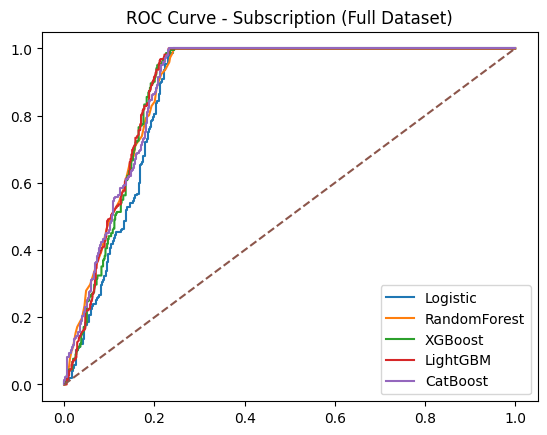

In [39]:
print("\n🔥 PART 1 — FULL DATASET EVALUATION")

plt.figure()

for name, model in models_full.items():
    model.fit(X1_train, y1_train)
    evaluate_model(model, X1_test, y1_test, name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Subscription (Full Dataset)")
plt.legend()
plt.show()


🔥 PART 1 — ANOVA DATASET EVALUATION

===== Logistic =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8781

Confusion Matrix:
 [[422 136]
 [  0 222]]

===== RandomForest =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8781

Confusion Matrix:
 [[422 136]
 [  0 222]]

===== XGBoost =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8781

Confusion Matrix:
 [[422 136]
 [  0 222]]

===== LightGBM =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8781

Confusion Matrix:
 [[422 136]
 [  0 222]]

===== CatBoost =====
Accuracy : 0.8256
Precision: 0.6201
Recall   : 1.0
F1 Score : 0.7655
ROC-AUC  : 0.8781

Confusion Matrix:
 [[422 136]
 [  0 222]]


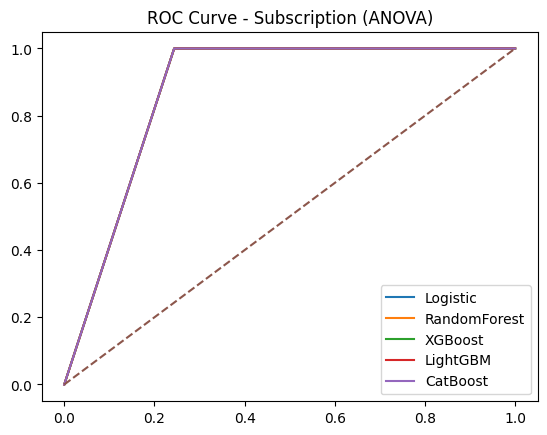

In [40]:
print("\n🔥 PART 1 — ANOVA DATASET EVALUATION")

plt.figure()

for name, model in models_anova.items():
    model.fit(X1_train51, y1_train)
    evaluate_model(model, X1_test51, y1_test, name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Subscription (ANOVA)")
plt.legend()
plt.show()

In [41]:
def evaluate_model(model, X2_test, y2_test, name):
    
    y2_pred = model.predict(X2_test)

    # ROC safe
    if hasattr(model, "predict_proba"):
        y2_prob = model.predict_proba(X2_test)[:,1]
    else:
        y2_prob = y2_pred

    print(f"\n===== {name} =====")
    
    print("Accuracy :", round(accuracy_score(y2_test, y2_pred),4))
    print("Precision:", round(precision_score(y2_test, y2_pred, zero_division=0),4))
    print("Recall   :", round(recall_score(y2_test, y2_pred, zero_division=0),4))
    print("F1 Score :", round(f1_score(y2_test, y2_pred, zero_division=0),4))
    print("ROC-AUC  :", round(roc_auc_score(y2_test, y2_prob),4))

    print("\nConfusion Matrix:\n", confusion_matrix(y2_test, y2_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y2_test, y2_prob)
    plt.plot(fpr, tpr, label=name)


🔥 PART 2 — FULL DATASET EVALUATION

===== Logistic =====
Accuracy : 0.6821
Precision: 0.6742
Recall   : 0.6452
F1 Score : 0.6593
ROC-AUC  : 0.7537

Confusion Matrix:
 [[292 116]
 [132 240]]

===== RandomForest =====
Accuracy : 0.8897
Precision: 0.8405
Recall   : 0.9489
F1 Score : 0.8914
ROC-AUC  : 0.9714

Confusion Matrix:
 [[341  67]
 [ 19 353]]

===== XGBoost =====
Accuracy : 0.9115
Precision: 0.8499
Recall   : 0.9892
F1 Score : 0.9143
ROC-AUC  : 0.9892

Confusion Matrix:
 [[343  65]
 [  4 368]]

===== LightGBM =====
Accuracy : 0.9103
Precision: 0.8495
Recall   : 0.9866
F1 Score : 0.9129
ROC-AUC  : 0.9903

Confusion Matrix:
 [[343  65]
 [  5 367]]

===== CatBoost =====
Accuracy : 0.8744
Precision: 0.8031
Recall   : 0.9758
F1 Score : 0.8811
ROC-AUC  : 0.9833

Confusion Matrix:
 [[319  89]
 [  9 363]]


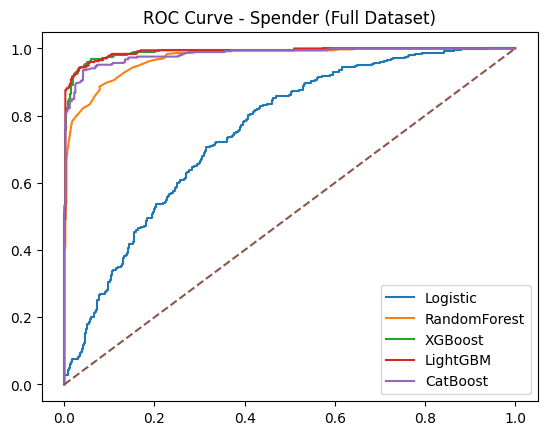

In [42]:
print("\n🔥 PART 2 — FULL DATASET EVALUATION")

plt.figure()

for name, model in models_full.items():
    model.fit(X2_train, y2_train)
    evaluate_model(model, X2_test, y2_test, name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Spender (Full Dataset)")
plt.legend()
plt.show()


🔥 PART 2 — ANOVA DATASET EVALUATION

===== Logistic =====
Accuracy : 0.6782
Precision: 0.6806
Recall   : 0.6129
F1 Score : 0.645
ROC-AUC  : 0.7863

Confusion Matrix:
 [[301 107]
 [144 228]]

===== RandomForest =====
Accuracy : 0.8346
Precision: 0.7475
Recall   : 0.9866
F1 Score : 0.8505
ROC-AUC  : 0.9654

Confusion Matrix:
 [[284 124]
 [  5 367]]

===== XGBoost =====
Accuracy : 0.7577
Precision: 0.6673
Recall   : 0.9812
F1 Score : 0.7943
ROC-AUC  : 0.9095

Confusion Matrix:
 [[226 182]
 [  7 365]]

===== LightGBM =====
Accuracy : 0.7795
Precision: 0.6866
Recall   : 0.9892
F1 Score : 0.8106
ROC-AUC  : 0.9421

Confusion Matrix:
 [[240 168]
 [  4 368]]


C:\Users\simpl\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\simpl\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== CatBoost =====
Accuracy : 0.7654
Precision: 0.6766
Recall   : 0.9731
F1 Score : 0.7982
ROC-AUC  : 0.9165

Confusion Matrix:
 [[235 173]
 [ 10 362]]


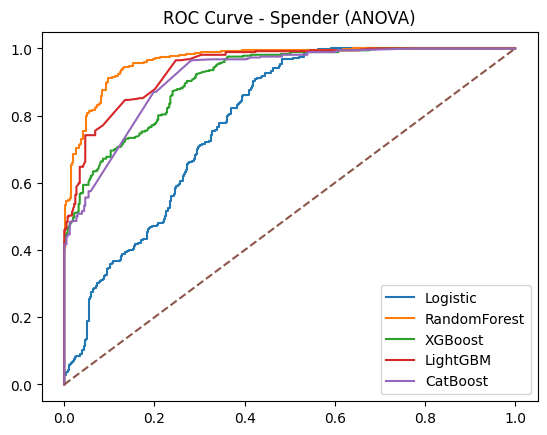

In [43]:
print("\n🔥 PART 2 — ANOVA DATASET EVALUATION")

plt.figure()

for name, model in models_anova.items():
    model.fit(X2_train_anova, y2_train)
    evaluate_model(model, X2_test_anova, y2_test, name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Spender (ANOVA)")
plt.legend()
plt.show()

In [1]:
!python -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ------------------------------------- -- 524.3/559.2 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 559.2/559.2 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.0/39.2 MB 2.9 MB/s eta 0:00:14
   - -------------------------------------- 1.6/39.2 MB 2.6 MB/s eta 0:00:15
   -- ------------------------------------- 2.4/39.2 MB 2.9 MB/s eta 0:00:13
   --- ------------------------------------ 3.1/39.2 MB 3.1 MB/s eta 0:00:12
   --- ------------------------------------ 3.7/39.2 MB 3.0 MB/s eta 0:00:12
   ----- ---------------------------------- 5.0/39.2 MB 3.5 MB/s eta 0:00:10
   ------ --------------------------------- 6.3/39.2 MB 3.8 MB/s eta 0:00:09
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


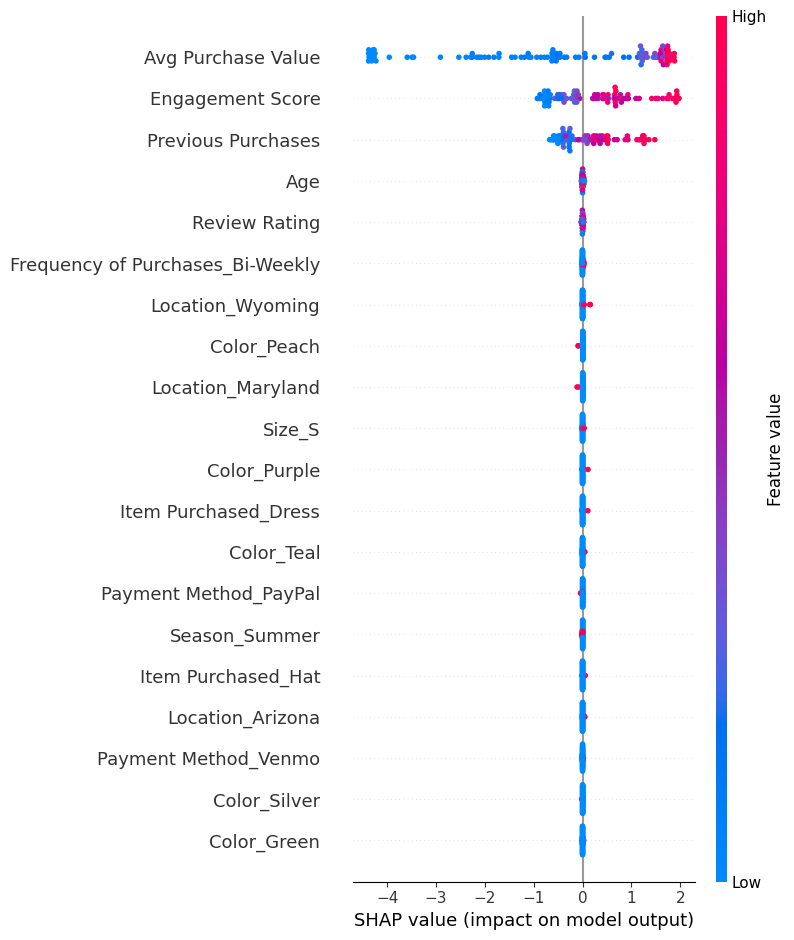

In [44]:

import shap

# Train BEST MODEL again (important)
best_model = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

best_model.fit(X2_train, y2_train)

# SHAP Explainer
explainer = shap.Explainer(best_model)

# Take sample (faster)
X2_sample = X2_test.sample(100, random_state=42)

shap_values = explainer(X2_sample)

# Summary Plot
shap.summary_plot(shap_values, X2_sample)